# *ASSIGNMENT-2: Network robustness*

In [46]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import random
from itertools import combinations

### Function

In [47]:
def giant_component_size(G):
    if len(G) == 0:
        return 0
    return len(max(nx.connected_components(G), key=len))

In [48]:
def keep_largest_component(G):
    if len(G) == 0:
        return G
    largest = max(nx.connected_components(G), key=len)
    return G.subgraph(largest).copy()

In [49]:
def attack(G, strategy, step=1):
    G = G.copy()
    N = G.number_of_nodes()
    removed_nodes = 0
    removed = []
    giant = []
    iteration = 0

    print(f"\n===== {strategy.upper()} ATTACK =====")
    print(f"Initial nodes: {N}")
    while G.number_of_nodes() > 0:
        iteration += 1
        k = min(step, G.number_of_nodes())

        if strategy == "random":
            nodes = random.sample(list(G.nodes()), k)

        elif strategy == "degree":
            nodes = sorted(G.degree, key=lambda x: x[1], reverse=True)[:k]
            nodes = [n for n, _ in nodes]

        elif strategy == "pagerank":
            pr = nx.pagerank(G)
            nodes = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:k]
            nodes = [n for n, _ in nodes]

        elif strategy == "betweenness":
            bc = nx.betweenness_centrality(G)
            nodes = sorted(bc.items(), key=lambda x: x[1], reverse=True)[:k]
            nodes = [n for n, _ in nodes]

        else:
            raise ValueError("Unknown strategy")

        print(f"\nIteration {iteration}")
        print(f"Removing nodes: {nodes}")
        G.remove_nodes_from(nodes)
        removed_nodes += len(nodes)

        if G.number_of_nodes() == 0:
            print("Graph is empty.")
            break

        components = list(nx.connected_components(G))
        largest = max(components, key=len)

        print(f"Remaining nodes: {G.number_of_nodes()}")
        print(f"Connected components: {len(components)}")
        print(f"Largest component size: {len(largest)}")

        if len(components) > 1:
            print(f"Graph split. Keeping largest component ({len(largest)} nodes).")

        removed.append(removed_nodes / N)
        giant.append(len(largest) / N)

        if len(components) > 1:
            print(f"Graph split into {len(components)} components.")
            print(f"Keeping largest component ({len(largest)} nodes).")
            G = G.subgraph(largest).copy()

    print("\nAttack completed.")
    return removed, giant

## Use small graphs to write the code


===== RANDOM ATTACK =====
Initial nodes: 500

Iteration 1
Removing nodes: [45, 497, 419, 390, 226]
Remaining nodes: 495
Connected components: 1
Largest component size: 495

Iteration 2
Removing nodes: [345, 338, 136, 478, 362]
Remaining nodes: 490
Connected components: 1
Largest component size: 490

Iteration 3
Removing nodes: [191, 3, 135, 168, 475]
Remaining nodes: 485
Connected components: 1
Largest component size: 485

Iteration 4
Removing nodes: [237, 27, 441, 258, 463]
Remaining nodes: 480
Connected components: 1
Largest component size: 480

Iteration 5
Removing nodes: [230, 145, 283, 205, 322]
Remaining nodes: 475
Connected components: 1
Largest component size: 475

Iteration 6
Removing nodes: [54, 462, 299, 7, 77]
Remaining nodes: 470
Connected components: 1
Largest component size: 470

Iteration 7
Removing nodes: [385, 436, 414, 412, 296]
Remaining nodes: 465
Connected components: 1
Largest component size: 465

Iteration 8
Removing nodes: [396, 366, 276, 314, 379]
Remaining n

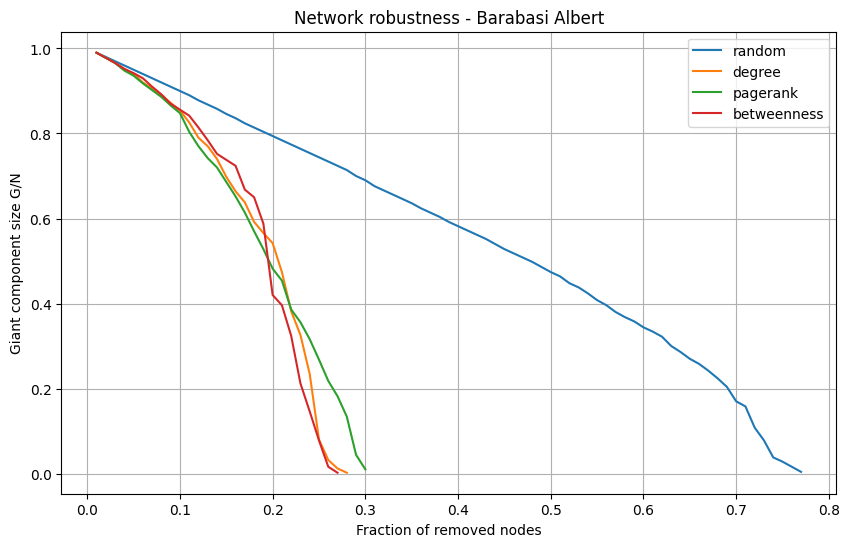

In [51]:
G = nx.barabasi_albert_graph(500, 3)
strategies = [
    "random",
    "degree",
    "pagerank",
    "betweenness"
]

plt.figure(figsize=(10, 6))
for strategy in strategies:
    x, y = attack(G, strategy, step=5)
    print(strategy)
    print("Points:", len(x))
    print("First values:", x[:5], y[:5])
    print("Last values:", x[-5:], y[-5:])
    print()

    plt.plot(x, y, label=strategy)

plt.xlabel("Fraction of removed nodes")
plt.ylabel("Giant component size G/N")
plt.title("Network robustness - Barabasi Albert")
plt.legend()
plt.grid()
plt.show()

## Use your graph

In [ ]:
BASE_DIR = Path().resolve().parent
DATASET_PATH = BASE_DIR / "data" / "anime_filtered.csv"
df = pd.read_csv(DATASET_PATH)

In [ ]:
def build_graph(filtered):
    G = nx.Graph()
    for _, row in filtered.iterrows():
        G.add_node(row["mal_id"], title=row["title"])
    for (_, a), (_, b) in combinations(filtered.iterrows(), 2):
        genres_a = set(str(a["genres"]).split("|"))
        genres_b = set(str(b["genres"]).split("|"))
        if len(genres_a & genres_b) >= 2:
            G.add_edge(a["mal_id"], b["mal_id"])
    return G

In [ ]:
G = build_graph(filtered=df)
print(G.number_of_nodes())
print(G.number_of_edges())

In [ ]:
def giant_component(G):
    if G.number_of_nodes() == 0:
        return 0, G

    largest = max(nx.connected_components(G), key=len)
    return len(largest), G.subgraph(largest).copy()

In [ ]:
def attack(G, strategy, step=0.05):
    G = G.copy()
    N = G.number_of_nodes()
    results = []

    while len(results) < int(1 / step):
        if G.number_of_nodes() == 0:
            results.append(0)
            continue
        remove_number = min(max(1, int(G.number_of_nodes() * step)), G.number_of_nodes())
        if strategy == "random":
            nodes = random.sample(list(G.nodes()), remove_number)
        elif strategy == "degree":
            nodes = [
                n for n, d in
                sorted(G.degree(), key=lambda x: x[1], reverse=True)[:remove_number]
            ]
        elif strategy == "pagerank":
            pr = nx.pagerank(G)
            nodes = sorted(pr, key=pr.get, reverse=True)[:remove_number]
        elif strategy == "betweenness":
            k = min(500, G.number_of_nodes())
            bc = nx.betweenness_centrality(G, k=k)
            nodes = sorted(bc, key=bc.get, reverse=True)[:remove_number]
        G.remove_nodes_from(nodes)
        size, G = giant_component(G)
        results.append(size / N)
    return results

## Testing on a NetworkX synthetic graph

In [ ]:
G_test = nx.barabasi_albert_graph(
    n=500,
    m=3,
    seed=42
)

print("Test graph")
print("Nodes:", G_test.number_of_nodes())
print("Edges:", G_test.number_of_edges())

In [ ]:
random_test = attack(G_test, "random")
degree_test = attack(G_test, "degree")
pagerank_test = attack(G_test, "pagerank")
betweenness_test = attack(G_test, "betweenness")

In [ ]:
print(len(random_test))
print(len(degree_test))
print(len(pagerank_test))
print(len(betweenness_test))

In [ ]:
x_test = [i * 0.05 for i in range(1, 21)]

plt.figure(figsize=(10,6))

plt.plot(x_test, random_test, label="Random")
plt.plot(x_test, degree_test, label="Degree")
plt.plot(x_test, pagerank_test, label="PageRank")
plt.plot(x_test, betweenness_test, label="Betweenness")

plt.xlabel("Fraction of removed nodes")
plt.ylabel("G/N")
plt.title("Robustness analysis on Barabási-Albert graph")

plt.xlim(0,1)
plt.ylim(0,1)
plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [ ]:
def critical_threshold(G):
    degrees = [d for _, d in G.degree()]
    k1 = sum(degrees) / len(degrees)
    k2 = sum(d*d for d in degrees) / len(degrees)
    fc = 1 - 1 / ((k2 / k1) - 1)
    return k1, k2, fc

In [ ]:
random_result = attack(G, "random")
degree_result = attack(G, "degree")
pagerank_result = attack(G, "pagerank")
betweenness_result = attack(G, "betweenness")

In [ ]:
print(len(random_result))
print(len(degree_result))
print(len(pagerank_result))
print(len(betweenness_result))

In [ ]:
plt.figure(figsize=(10,6))

x = [i*0.05 for i in range(1, 21)]

plt.plot(x, random_result, label="Random")
plt.plot(x, degree_result, label="Degree")
plt.plot(x, pagerank_result, label="PageRank")
plt.plot(x, betweenness_result, label="Betweenness")

plt.xlabel("Fraction of removed nodes")
plt.ylabel("G/N")
plt.xlim(0,1)
plt.ylim(0,1)
plt.grid(alpha=0.3)
plt.legend()

plt.show()

## Building robustness

In [ ]:
G_improved = G.copy()
top_nodes = sorted(
    G_improved.degree(),
    key=lambda x: x[1],
    reverse=True
)[:3]

for node, degree in top_nodes:
    neighbors = list(G_improved.neighbors(node))
    for i in range(len(neighbors)):
        for j in range(i + 1, len(neighbors)):
            if not G_improved.has_edge(neighbors[i], neighbors[j]):
                G_improved.add_edge(neighbors[i], neighbors[j])

print("Nodes:", G_improved.number_of_nodes())
print("Edges:", G_improved.number_of_edges())

In [ ]:
k1, k2, fc = critical_threshold(G_improved)

print("First moment:", k1)
print("Second moment:", k2)
print("Critical threshold:", fc)

In [ ]:
random_result_improved = attack(G_improved, "random")
degree_result_improved = attack(G_improved, "degree")
pagerank_result_improved = attack(G_improved, "pagerank")
betweenness_result_improved = attack(G_improved, "betweenness")

In [ ]:
print(len(random_result_improved))
print(len(degree_result_improved))
print(len(pagerank_result_improved))
print(len(betweenness_result_improved))

In [ ]:
x = [i*0.05 for i in range(1,21)]

plt.figure(figsize=(10,6))

plt.plot(x, random_result_improved, label="Random")
plt.plot(x, degree_result_improved, label="Degree")
plt.plot(x, pagerank_result_improved, label="PageRank")
plt.plot(x, betweenness_result_improved, label="Betweenness")

plt.xlabel("Fraction of removed nodes")
plt.ylabel("G/N")
plt.xlim(0,1)
plt.ylim(0,1)
plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [ ]:
G_betweenness = G.copy()
bc = nx.betweenness_centrality(G_betweenness)
top_nodes = sorted(bc, key=bc.get, reverse=True)[:3]

for node in top_nodes:
    neighbors = list(G_betweenness.neighbors(node))
    for i in range(len(neighbors)):
        for j in range(i + 1, len(neighbors)):
            if not G_betweenness.has_edge(neighbors[i], neighbors[j]):
                G_betweenness.add_edge(neighbors[i], neighbors[j])

print("Nodes:", G_betweenness.number_of_nodes())
print("Edges:", G_betweenness.number_of_edges())

k1, k2, fc = critical_threshold(G_betweenness)
print("First moment:", k1)
print("Second moment:", k2)
print("Critical threshold:", fc)

In [ ]:
results_fc = []

for name, graph in [
    ("Original", G),
    ("Degree-based rings", G_improved),
    ("Betweenness-based rings", G_betweenness)
]:
    k1, k2, fc = critical_threshold(graph)

    results_fc.append([
        name,
        graph.number_of_nodes(),
        graph.number_of_edges(),
        k1,
        k2,
        fc
    ])

fc_table = pd.DataFrame(
    results_fc,
    columns=[
        "Graph",
        "Nodes (N)",
        "Edges (L)",
        "First moment <k>",
        "Second moment <k²>",
        "Critical threshold fc"
    ]
)

display(fc_table)